<a href="https://colab.research.google.com/github/shreyasat27/mahework2025/blob/main/Zeeman_splitting_of_RP_energy_levels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Zeeman
splitting of RP energy levels (J < 0). aeff rep-
resents an effective hyperfine coupling. The
energy scale is arbitrary.

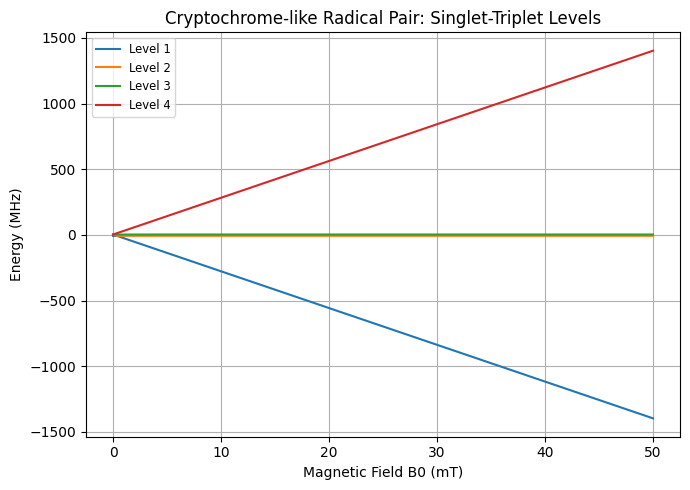

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Effective hyperfine strengths (MHz)
a_eff_trp = 5.0
a_eff_luf = 4.0

# Exchange J in MHz
J_MHz = 10.0  #J ~ 0.01–100 MHz.

# g-factor
g = 2.0
zeeman_per_T = g * 13996.24555  # MHz/T



# Magnetic field range (0–50 mT)
B_T = np.linspace(0.0, 0.050, 400)

# Singlet-triplet mixing
delta_a = a_eff_trp - a_eff_luf
mix_ST0 = delta_a / 2.0

# Triplet/Singlet center energies
E_triplet_center = 0.25 * J_MHz
E_singlet = -0.75 * J_MHz

eigvals = np.zeros((len(B_T), 4))

for i, B in enumerate(B_T):
    # Zeeman splitting
    E_Tp1 = E_triplet_center + zeeman_per_T * B
    E_T0  = E_triplet_center
    E_Tm1 = E_triplet_center - zeeman_per_T * B
    E_S   = E_singlet

    # Hamiltonian [T+1, T0, S, T-1]
    H = np.zeros((4,4))
    H[0,0] = E_Tp1
    H[1,1] = E_T0
    H[2,2] = E_S
    H[3,3] = E_Tm1
    H[1,2] = mix_ST0
    H[2,1] = mix_ST0

    vals = np.linalg.eigvalsh(H)
    eigvals[i,:] = np.sort(vals)

# Plot
plt.figure(figsize=(7,5))
for j in range(4):
    plt.plot(B_T*1000, eigvals[:,j], label=f'Level {j+1}')
plt.xlabel('Magnetic Field B0 (mT)')
plt.ylabel('Energy (MHz)')
plt.title('Cryptochrome-like Radical Pair: Singlet-Triplet Levels')
plt.grid(True)
plt.legend(fontsize='small')
plt.tight_layout()
plt.show()
